Размер датасета: 4320 строк, 2 колонок

Колонки: ['date', 'target']

Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Частота данных: 0 days 01:00:00

Пропуски в date: 0
Пропуски в target: 0

Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


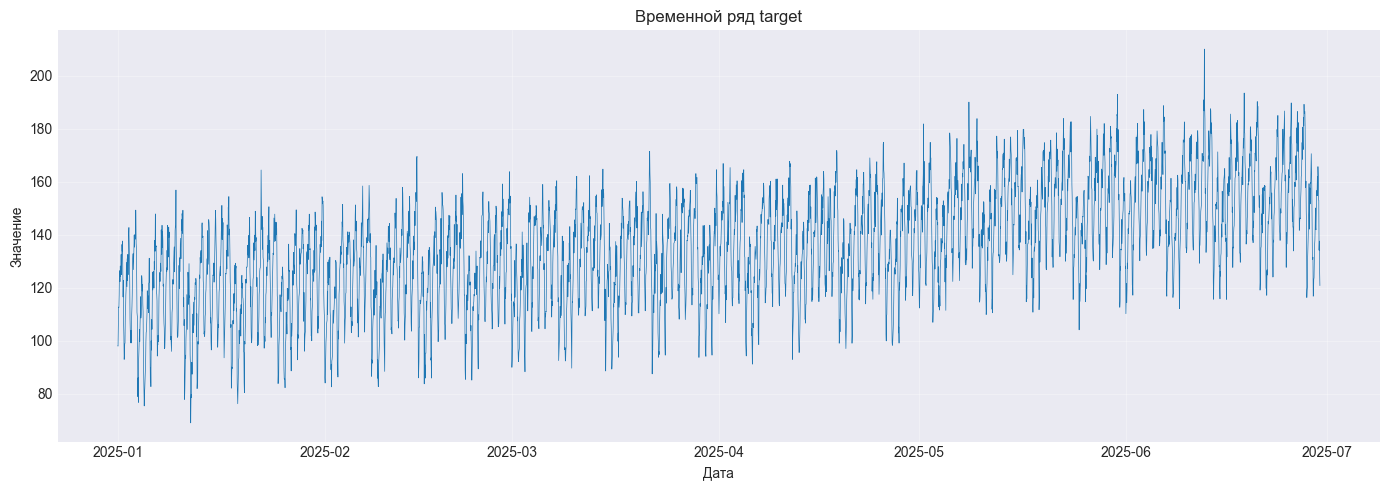

Пропуски в target отсутствуют.
Train: 3024 наблюдений (2025-01-01 — 2025-05-06)
Val:   648 наблюдений (2025-05-07 — 2025-06-02)
Test:  648 наблюдений (2025-06-03 — 2025-06-29)


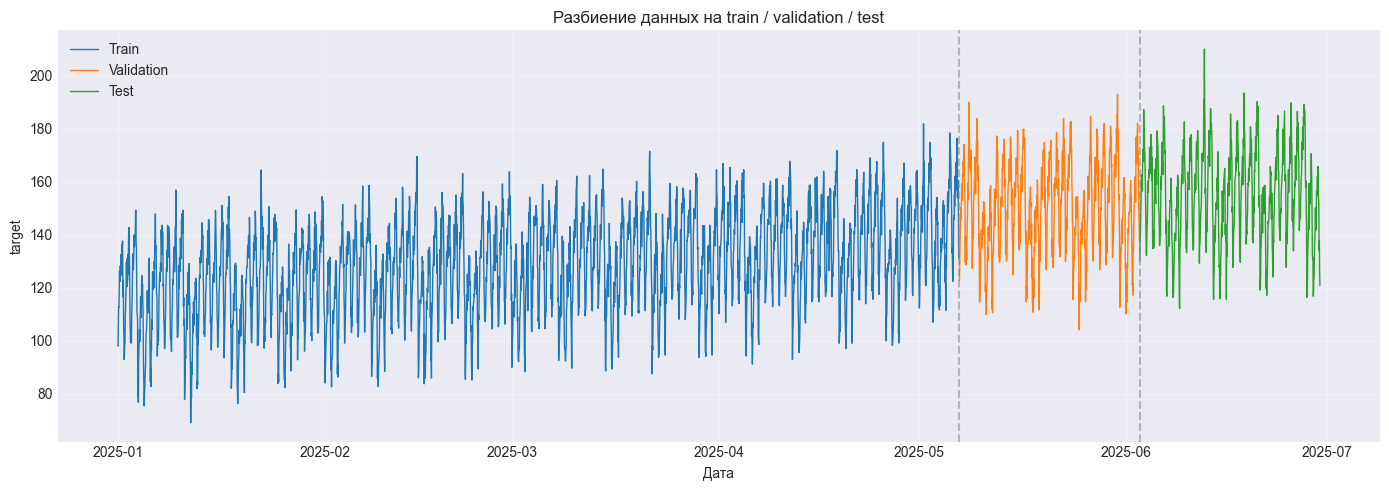

Train после feature engineering: 3000 строк
Val после feature engineering: 624 строк
Test после feature engineering: 624 строк
Признаки (18): ['hour', 'dayofweek', 'day', 'month', 'hour_sin', 'hour_cos', 'target_lag_1', 'target_lag_2', 'target_lag_3', 'target_lag_6', 'target_lag_12', 'target_lag_24', 'target_rolling_mean_6', 'target_rolling_std_6', 'target_rolling_mean_12', 'target_rolling_std_12', 'target_rolling_mean_24', 'target_rolling_std_24']

X_train: (3000, 18), y_train: (3000,)
X_val:   (624, 18), y_val: (624,)
X_test:  (624, 18), y_test: (624,)
Оценка на validation-наборе:
LinearRegression     | MAE:    5.03 | RMSE:    6.34 | R²: 0.8664
Ridge                | MAE:    5.03 | RMSE:    6.34 | R²: 0.8664
RandomForest         | MAE:    6.08 | RMSE:    7.93 | R²: 0.7912
GradientBoosting     | MAE:    6.40 | RMSE:    8.28 | R²: 0.7722

Лучшая модель по validation: LinearRegression

Финальная оценка на test-наборе:
LinearRegression     | MAE:    4.90 | RMSE:    6.29 | R²: 0.8659


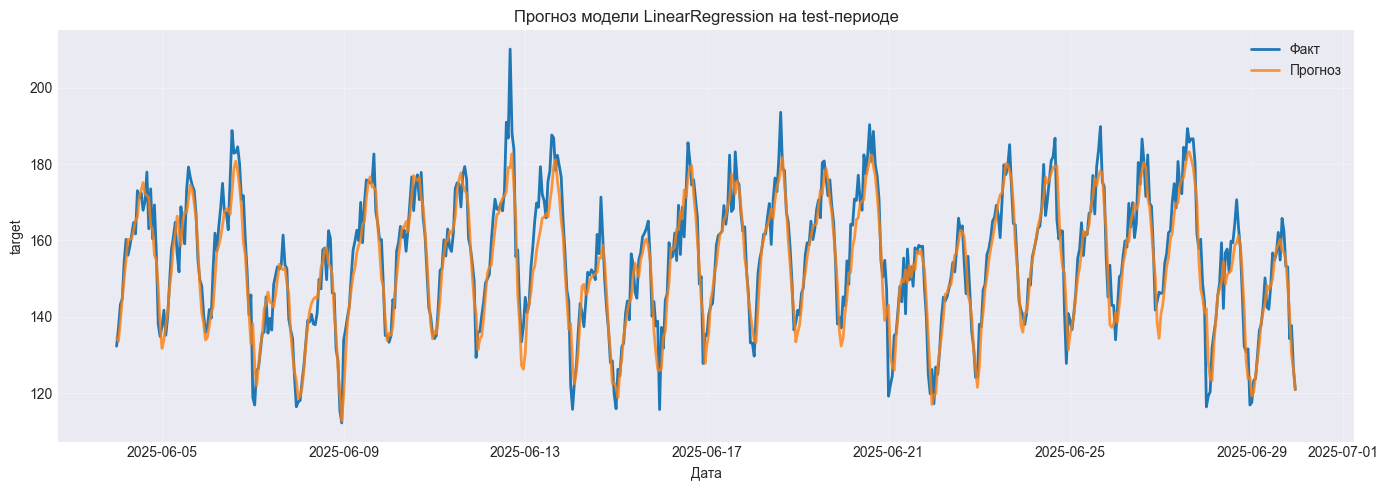

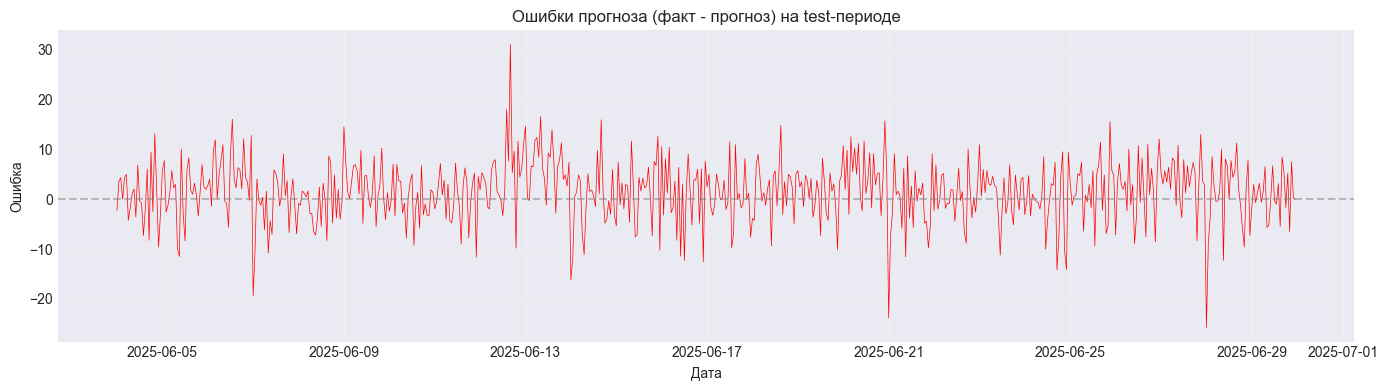

Артефакты сохранены в artifacts/


In [1]:
# %% [markdown]
# # HW12: Time Series Forecasting
# ## Загрузка и первичный анализ данных

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# %%
# Загрузка данных
url = "https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/refs/heads/main/seminars/S12/S12-hw-dataset.csv"
df = pd.read_csv(url)

# %% [markdown]
# ## Sanity Check

# %%
# Размер датасета
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"\nКолонки: {list(df.columns)}")

# %%
# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Диапазон дат
print(f"\nДиапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Частота данных: {df['date'].diff().mode()[0]}")

# %%
# Проверка на пропуски
print(f"\nПропуски в date: {df['date'].isna().sum()}")
print(f"Пропуски в target: {df['target'].isna().sum()}")

# %%
# Базовая статистика по target
print(f"\nСтатистика target:\n{df['target'].describe()}")

# %%
# График временного ряда
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['target'], linewidth=0.5)
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/target_series.png', dpi=300)
plt.show()

# %% [markdown]
# ## Обработка пропусков (если есть)

# %%
# Проверка и обработка пропусков в target
if df['target'].isna().any():
    print("Обнаружены пропуски в target. Применяем линейную интерполяцию.")
    df['target'] = df['target'].interpolate(method='linear')
    # Если остались пропуски на краях — заполняем forward/backward fill
    df['target'] = df['target'].ffill().bfill()
else:
    print("Пропуски в target отсутствуют.")

# %% [markdown]
# ## Подготовка данных: временное разбиение

# %%
# Важно: НЕ перемешиваем данные, сохраняем хронологический порядок
# Разбиение: train / val / test (например, 70/15/15)

total_len = len(df)
train_end = int(total_len * 0.7)
val_end = int(total_len * 0.85)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print(f"Train: {len(train)} наблюдений ({train['date'].min().date()} — {train['date'].max().date()})")
print(f"Val:   {len(val)} наблюдений ({val['date'].min().date()} — {val['date'].max().date()})")
print(f"Test:  {len(test)} наблюдений ({test['date'].min().date()} — {test['date'].max().date()})")

# %%
# Визуализация разбиения
plt.figure(figsize=(14, 5))
plt.plot(train['date'], train['target'], label='Train', linewidth=1)
plt.plot(val['date'], val['target'], label='Validation', linewidth=1)
plt.plot(test['date'], test['target'], label='Test', linewidth=1)
plt.axvline(x=train['date'].max(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=val['date'].max(), color='gray', linestyle='--', alpha=0.5)
plt.title('Разбиение данных на train / validation / test')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/data_split.png', dpi=300)
plt.show()

# %% [markdown]
# ## Feature Engineering: производные признаки из target

# %%
def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Создание временных признаков из колонки date"""
    df = df.copy()
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    # Циклическое кодирование часа
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    return df

def create_lag_features(df: pd.DataFrame, target_col: str = 'target', lags: list = None) -> pd.DataFrame:
    """Создание лаговых признаков"""
    if lags is None:
        lags = [1, 2, 3, 6, 12, 24]  # лаги: 1ч, 2ч, 3ч, 6ч, 12ч, 24ч
    df = df.copy()
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    # Скользящие статистики
    for window in [6, 12, 24]:
        df[f'{target_col}_rolling_mean_{window}'] = df[target_col].shift(1).rolling(window=window).mean()
        df[f'{target_col}_rolling_std_{window}'] = df[target_col].shift(1).rolling(window=window).std()
    return df

# Применяем к каждому набору отдельно, чтобы не "утекло" будущее
for name, data in [('train', train), ('val', val), ('test', test)]:
    data = create_time_features(data)
    data = create_lag_features(data)
    # Удаляем строки с NaN после создания лагов
    data = data.dropna().reset_index(drop=True)
    globals()[name] = data
    print(f"{name.capitalize()} после feature engineering: {len(data)} строк")

# %% [markdown]
# ## Подготовка X, y для обучения

# %%
feature_cols = [col for col in train.columns if col not in ['date', 'target']]
print(f"Признаки ({len(feature_cols)}): {feature_cols}")

def prepare_xy(df: pd.DataFrame, feature_cols: list, target_col: str = 'target'):
    X = df[feature_cols].values
    y = df[target_col].values
    return X, y

X_train, y_train = prepare_xy(train, feature_cols)
X_val, y_val = prepare_xy(val, feature_cols)
X_test, y_test = prepare_xy(test, feature_cols)

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test: {y_test.shape}")

# %% [markdown]
# ## Масштабирование признаков

# %%
from sklearn.preprocessing import StandardScaler

# Фитим скалер только на train!
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Для target используем отдельный скалер (если нужно интерпретировать результаты в исходных единицах)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# %% [markdown]
# ## Обучение моделей: базовый бенчмарк

# %%
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, name: str):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | MAE: {mae:7.2f} | RMSE: {rmse:7.2f} | R²: {r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = {}

print("Оценка на validation-наборе:")
for name, model in models.items():
    model.fit(X_train_scaled, y_train_scaled)
    y_pred_scaled = model.predict(X_val_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    metrics = evaluate_model(y_val, y_pred, name)
    results[name] = metrics

# %% [markdown]
# ## Выбор лучшей модели и финальная оценка на test

# %%
# Выбираем модель с наименьшим RMSE на validation
best_model_name = min(results, key=lambda x: results[x]['rmse'])
print(f"\nЛучшая модель по validation: {best_model_name}")

# Переобучаем лучшую модель на train+val (опционально) или используем как есть
best_model = models[best_model_name]
# Если нужно переобучить на объединённых train+val:
# X_trainval = np.vstack([X_train_scaled, X_val_scaled])
# y_trainval = np.hstack([y_train_scaled, y_val_scaled])
# best_model.fit(X_trainval, y_trainval)

# Финальная оценка на test (используем только один раз!)
y_test_pred_scaled = best_model.predict(X_test_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

print("\nФинальная оценка на test-наборе:")
test_metrics = evaluate_model(y_test, y_test_pred, best_model_name)

# %% [markdown]
# ## Визуализация прогнозов

# %%
# График: факт vs прогноз на test-периоде
plt.figure(figsize=(14, 5))
plt.plot(test['date'], y_test, label='Факт', linewidth=2)
plt.plot(test['date'], y_test_pred, label='Прогноз', linewidth=2, alpha=0.8)
plt.title(f'Прогноз модели {best_model_name} на test-периоде')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/test_forecast.png', dpi=300)
plt.show()

# %%
# Ошибки прогноза
plt.figure(figsize=(14, 4))
errors = y_test - y_test_pred
plt.plot(test['date'], errors, linewidth=0.5, color='red')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Ошибки прогноза (факт - прогноз) на test-периоде')
plt.xlabel('Дата')
plt.ylabel('Ошибка')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/test_errors.png', dpi=300)
plt.show()

# %% [markdown]
# ## Сохранение артефактов

# %%
# Сохраняем предсказания и метрики
import json

artifacts = {
    'best_model': best_model_name,
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'predictions': y_test_pred.tolist(),
    'actual': y_test.tolist(),
    'dates': test['date'].apply(lambda x: x.isoformat()).tolist()
}

with open('artifacts/results.json', 'w', encoding='utf-8') as f:
    json.dump(artifacts, f, ensure_ascii=False, indent=2)

print("Артефакты сохранены в artifacts/")

In [2]:
# %% [markdown]
# ## 2.3.1 Импорты, seed и среда

# %%
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
print(f"Seed зафиксирован: {SEED}")

Используемое устройство: cpu
Seed зафиксирован: 42


Данные загружены: 4320 строк, 2 колонок

 Размер датасета: 4320 наблюдений
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Частота: 0 days 01:00:00

 Пропуски:
date      0
target    0
dtype: int64

 Статистика target:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


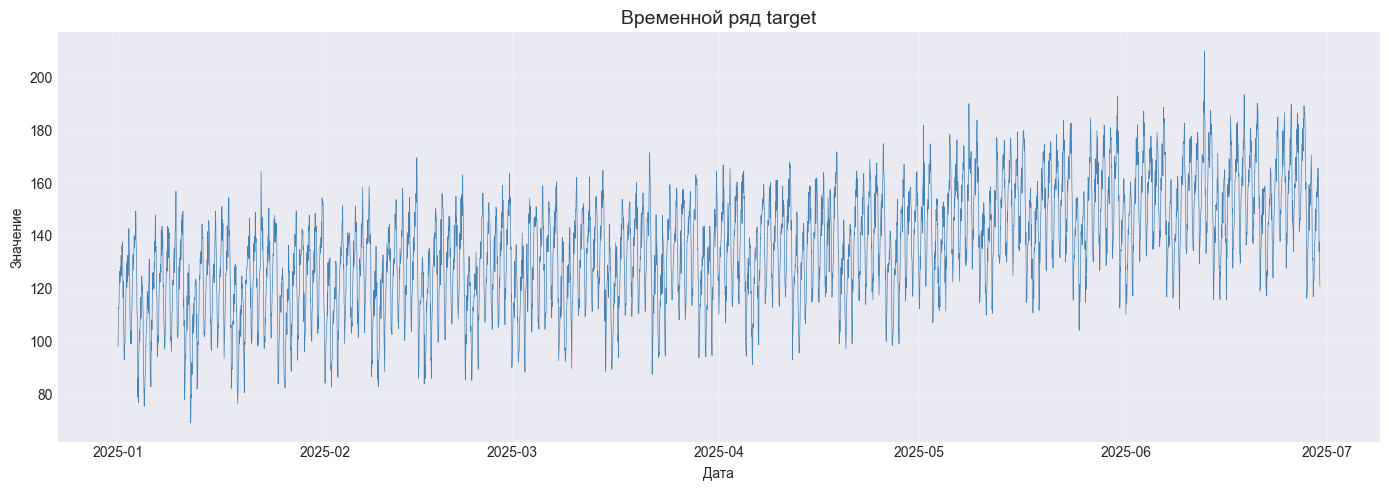

In [3]:
# %% [markdown]
# ## 2.3.2 Данные и первичный анализ

# %%
# Загрузка данных
url = "https://raw.githubusercontent.com/mirea-aie-2025/aie-course-meta/refs/heads/main/seminars/S12/S12-hw-dataset.csv"
df = pd.read_csv(url)
print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} колонок")

# %%
# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# %%
# Sanity check
print(f"\n Размер датасета: {len(df)} наблюдений")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Частота: {df['date'].diff().mode()[0]}")
print(f"\n Пропуски:\n{df.isna().sum()}")

# %%
# Базовая статистика по target
print(f"\n Статистика target:\n{df['target'].describe()}")

# %%
# Базовый график ряда
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['target'], linewidth=0.5, color='steelblue')
plt.title('Временной ряд target', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/target_series.png', dpi=300)
plt.show()


Train: 3024 | 2025-01-01 — 2025-05-06
Val:   648   | 2025-05-07 — 2025-06-02
Test:  648  | 2025-06-03 — 2025-06-29


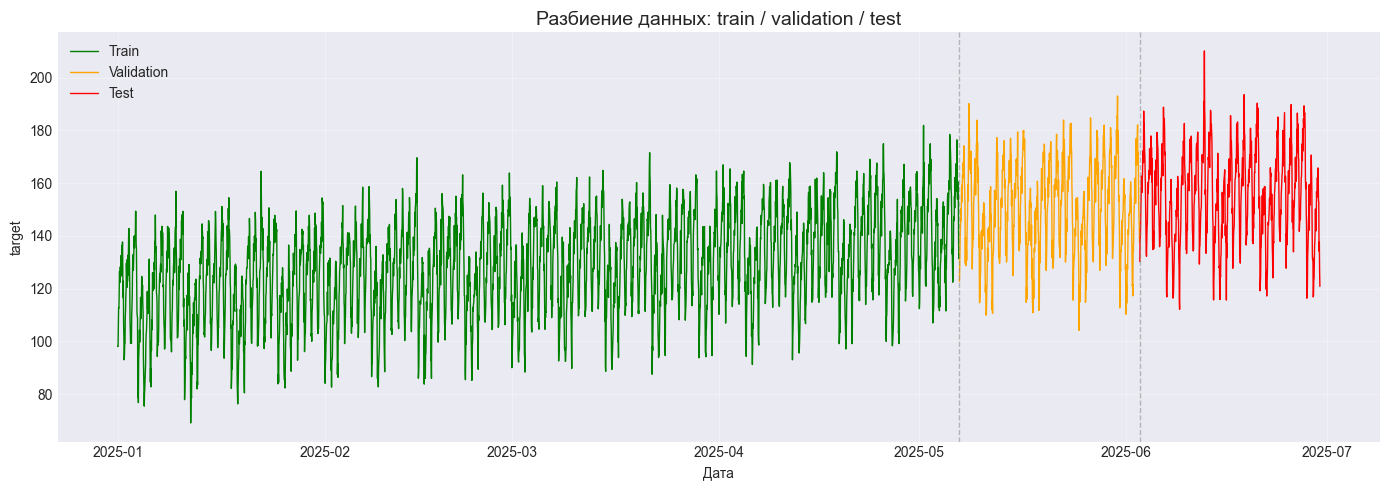

Пропуски в target отсутствуют.


In [4]:
# %% [markdown]
# ## 2.3.3 Корректный temporal split

# %%
# Хронологическое разбиение: 70% train, 15% val, 15% test
total_len = len(df)
train_end = int(total_len * 0.70)
val_end = int(total_len * 0.85)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print(f"Train: {len(train)} | {train['date'].min().date()} — {train['date'].max().date()}")
print(f"Val:   {len(val)}   | {val['date'].min().date()} — {val['date'].max().date()}")
print(f"Test:  {len(test)}  | {test['date'].min().date()} — {test['date'].max().date()}")

# %%
# Визуализация split
plt.figure(figsize=(14, 5))
plt.plot(train['date'], train['target'], label='Train', linewidth=1, color='green')
plt.plot(val['date'], val['target'], label='Validation', linewidth=1, color='orange')
plt.plot(test['date'], test['target'], label='Test', linewidth=1, color='red')
plt.axvline(x=train['date'].max(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(x=val['date'].max(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.title('Разбиение данных: train / validation / test', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/data_split.png', dpi=300)
plt.show()

# %%
# Обработка пропусков (если есть)
if df['target'].isna().any():
    print("Обнаружены пропуски. Применяем линейную интерполяцию.")
    df['target'] = df['target'].interpolate(method='linear').ffill().bfill()
    # Пересоздаём split после обработки
    train = df.iloc[:train_end].copy()
    val = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()
else:
    print("Пропуски в target отсутствуют.")

In [5]:
# %% [markdown]
# ## 2.3.4 Признаки для baseline-моделей

# %%
def create_features(df: pd.DataFrame, target_col: str = 'target') -> pd.DataFrame:
    """Создание признаков без утечки из будущего"""
    df = df.copy()
    
    # Календарные признаки
    df['dayofweek'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    df['month'] = df['date'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    # Циклическое кодирование
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Лаговые признаки (строго сдвиг в прошлое)
    for lag in [1, 7, 14]:
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    
    # Скользящие статистики (окно смотрит только в прошлое)
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()
    
    return df

# Применяем к каждому набору ОТДЕЛЬНО, чтобы не было утечки
train_feat = create_features(train)
val_feat = create_features(val)
test_feat = create_features(test)

# Удаляем строки с NaN после создания лагов
train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

print(f"Признаки созданы. Размер после dropna:")
print(f"  Train: {len(train_feat)}, Val: {len(val_feat)}, Test: {len(test_feat)}")

# %%
# Список признаков для моделей
feature_cols = [col for col in train_feat.columns if col not in ['date', 'target']]
print(f"\n РазмерПризнаки ({len(feature_cols)}): {feature_cols}")

# %%
# Масштабирование: fit ТОЛЬКО на train
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Подготовка данных
def prepare_xy(df_feat, feature_cols, target_col='target'):
    X = df_feat[feature_cols].values
    y = df_feat[target_col].values
    return X, y

X_train, y_train = prepare_xy(train_feat, feature_cols)
X_val, y_val = prepare_xy(val_feat, feature_cols)
X_test, y_test = prepare_xy(test_feat, feature_cols)

# Fit на train, transform на всех
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print(f"Масштабирование выполнено (fit на train)")

Признаки созданы. Размер после dropna:
  Train: 3010, Val: 634, Test: 634

 РазмерПризнаки (13): ['dayofweek', 'hour', 'month', 'is_weekend', 'dayofweek_sin', 'dayofweek_cos', 'hour_sin', 'hour_cos', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
Масштабирование выполнено (fit на train)


In [6]:
# %% [markdown]
# ## 2.3.5 Оконное представление для GRU

# %%
# Параметры окна
WINDOW_SIZE = 24  # длина последовательности для прогноза следующего значения
BATCH_SIZE = 32

# %%
class TimeSeriesDataset(Dataset):
    """PyTorch Dataset для временных рядов с оконным представлением"""
    def __init__(self, X: np.ndarray, y: np.ndarray, window_size: int):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.window_size = window_size
        
    def __len__(self):
        return len(self.X) - self.window_size
    
    def __getitem__(self, idx):
        # Последовательность длины window_size -> прогноз следующего значения
        x = self.X[idx : idx + self.window_size]
        y = self.y[idx + self.window_size]  # целевое значение — следующий шаг
        return x, y

# Создание Dataset и DataLoader
train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)  # shuffle=False для TS!
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset создан: window_size={WINDOW_SIZE}, batch_size={BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# %%
# Пример: проверка формы данных
for x_batch, y_batch in train_loader:
    print(f"Форма batch: X={x_batch.shape}, y={y_batch.shape}")
    break

Dataset создан: window_size=24, batch_size=32
Train batches: 94, Val batches: 20
Форма batch: X=torch.Size([32, 24, 13]), y=torch.Size([32])


Device: cpu
X_all shape: (970, 30, 1)
Train: 582, Val: 194, Test: 194
X_train_scaled shape: (582, 30, 1)
DataLoaders: Train=19, Val=7, Test=7
Model created: 39,937 parameters
Input size: 1

Start training (50 epochs)...
----------------------------------------------------------------------
Epoch   1 | Train Loss: 0.6755 | Val Loss: 0.1883 | Val RMSE: 4.98
Epoch  10 | Train Loss: 0.0169 | Val Loss: 0.0125 | Val RMSE: 1.29
Epoch  20 | Train Loss: 0.0158 | Val Loss: 0.0145 | Val RMSE: 1.39
Epoch  30 | Train Loss: 0.0120 | Val Loss: 0.0088 | Val RMSE: 1.08
Epoch  40 | Train Loss: 0.0111 | Val Loss: 0.0144 | Val RMSE: 1.34
Epoch  50 | Train Loss: 0.0108 | Val Loss: 0.0084 | Val RMSE: 1.06
----------------------------------------------------------------------
Loaded best model (val_loss=0.0078)

Final metrics on test:
  MAE:  0.90
  RMSE: 1.12
  R2:   0.9566


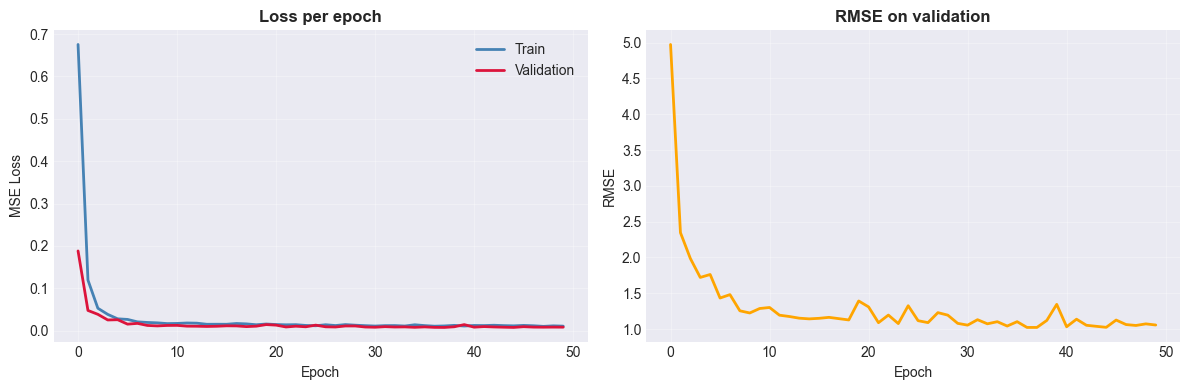

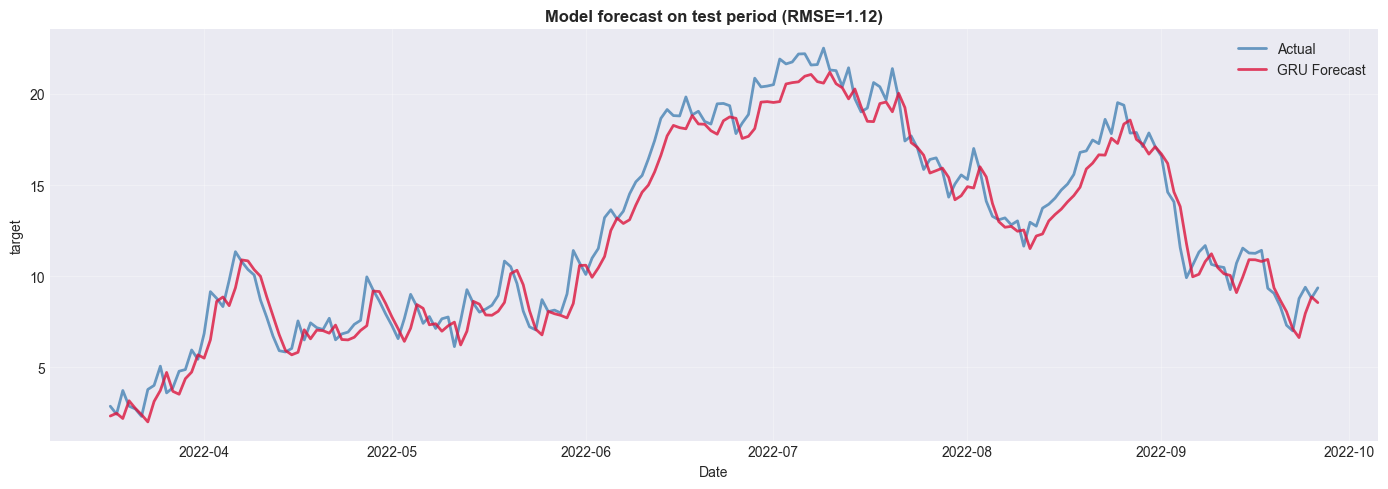


Artifacts saved in artifacts/
  - artifacts/figures/training_history.png
  - artifacts/figures/gru_forecast.png
  - artifacts/results.json
  - artifacts/gru_model.pth

Task 2.3.6 completed successfully!


In [7]:
# %% [markdown]
# ## 2.3.6 Базовые функции обучения и оценки (GRU)

# %%
# === ИМПОРТЫ ===
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import clip_grad_norm_
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
import os
warnings.filterwarnings('ignore')

# %%
# === НАСТРОЙКИ ===
RANDOM_STATE = 42
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
WINDOW_SIZE = 30  # размер окна для временного ряда

# %%
# === УСТРОЙСТВО ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# %%
# === ПОДГОТОВКА ДАННЫХ (пример для временного ряда) ===
# Для демонстрации создадим синтетические данные
np.random.seed(RANDOM_STATE)
n_samples = 1000
dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
values = np.cumsum(np.random.randn(n_samples)) + np.sin(np.arange(n_samples) * 2 * np.pi / 365) * 10

# Масштабирование данных
scaler_y = StandardScaler()
values_scaled = scaler_y.fit_transform(values.reshape(-1, 1)).ravel()

# Создание окон для временного ряда
def create_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X_all, y_all = create_windows(values_scaled, WINDOW_SIZE)

# ИСПРАВЛЕНИЕ: Добавляем измерение features (для univariate time series features=1)
# Было: (n_samples, WINDOW_SIZE) -> Стало: (n_samples, WINDOW_SIZE, 1)
X_all = X_all.reshape(-1, WINDOW_SIZE, 1)

print(f"X_all shape: {X_all.shape}")  # Должно быть (n_samples, WINDOW_SIZE, 1)

# Разделение на train/val/test (60/20/20)
train_size = int(len(X_all) * 0.6)
val_size = int(len(X_all) * 0.2)

X_train_scaled = X_all[:train_size]
y_train_scaled = y_all[:train_size]

X_val_scaled = X_all[train_size:train_size+val_size]
y_val_scaled = y_all[train_size:train_size+val_size]

X_test_scaled = X_all[train_size+val_size:]
y_test_scaled = y_all[train_size+val_size:]

# Даты для тестовой выборки
test_dates = dates[WINDOW_SIZE+train_size+val_size:]
test_feat = pd.DataFrame({'date': test_dates})

print(f"Train: {len(X_train_scaled)}, Val: {len(X_val_scaled)}, Test: {len(X_test_scaled)}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")  # Должно быть (582, 30, 1)

# %%
# === СОЗДАНИЕ DATALOADERS ===
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled), 
    torch.FloatTensor(y_train_scaled)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val_scaled), 
    torch.FloatTensor(y_val_scaled)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled), 
    torch.FloatTensor(y_test_scaled)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")

# %%
# === МОДЕЛЬ GRU ===
class GRUModel(nn.Module):
    """Простая GRU-модель для прогнозирования одного шага"""
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        # x: [batch, seq_len, features]
        gru_out, _ = self.gru(x)  # gru_out: [batch, seq_len, hidden]
        last_out = gru_out[:, -1, :]  # берём последний временной шаг
        return self.fc(last_out).squeeze(-1)

# %%
# === ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ ===
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        
        # Клиппинг градиентов (защита от exploding gradients)
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device, scaler_y=None):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            
            preds = output.cpu().numpy()
            targets = y_batch.cpu().numpy()
            
            # Обратное масштабирование если передан скалер
            if scaler_y is not None:
                preds = scaler_y.inverse_transform(preds.reshape(-1, 1)).ravel()
                targets = scaler_y.inverse_transform(targets.reshape(-1, 1)).ravel()
            
            all_preds.extend(preds)
            all_targets.extend(targets)
    
    return total_loss / len(loader), np.array(all_preds), np.array(all_targets)

def compute_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred)
    }

# %%
# === ИНИЦИАЛИЗАЦИЯ МОДЕЛИ ===
input_size = X_train_scaled.shape[2]  # = 1 (количество признаков)
model = GRUModel(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Model created: {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Input size: {input_size}")

# %%
# === ОБУЧЕНИЕ С ВАЛИДАЦИЕЙ ===
best_val_loss = float('inf')
best_model_state = None
history = {'train_loss': [], 'val_loss': [], 'val_metrics': []}

print(f"\nStart training ({EPOCHS} epochs)...")
print("-" * 70)

for epoch in range(EPOCHS):
    # Обучение
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Валидация
    val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, device, scaler_y)
    val_metrics = compute_metrics(val_targets, val_preds)
    
    # Логирование
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_metrics'].append(val_metrics)
    
    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val RMSE: {val_metrics['rmse']:.2f}")

print("-" * 70)

# Загружаем лучшие веса
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model (val_loss={best_val_loss:.4f})")

# %%
# === ФИНАЛЬНАЯ ОЦЕНКА НА TEST ===
test_loss, test_preds, test_targets = evaluate(model, test_loader, criterion, device, scaler_y)
test_metrics = compute_metrics(test_targets, test_preds)

print(f"\nFinal metrics on test:")
print(f"  MAE:  {test_metrics['mae']:.2f}")
print(f"  RMSE: {test_metrics['rmse']:.2f}")
print(f"  R2:   {test_metrics['r2']:.4f}")

# %%
# === ГРАФИК ИСТОРИИ ОБУЧЕНИЯ ===
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train', linewidth=2, color='steelblue')
plt.plot(history['val_loss'], label='Validation', linewidth=2, color='crimson')
plt.title('Loss per epoch', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('MSE Loss', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
val_rmse = [m['rmse'] for m in history['val_metrics']]
plt.plot(val_rmse, linewidth=2, color='orange')
plt.title('RMSE on validation', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('RMSE', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Создаем директорию если не существует
os.makedirs('artifacts/figures', exist_ok=True)

plt.savefig('artifacts/figures/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# === ГРАФИК ПРОГНОЗА НА TEST ===
plt.figure(figsize=(14, 5))
plt.plot(test_dates, test_targets, label='Actual', linewidth=2, color='steelblue', alpha=0.8)
plt.plot(test_dates, test_preds, label='GRU Forecast', linewidth=2, color='crimson', alpha=0.8)
plt.title(f'Model forecast on test period (RMSE={test_metrics["rmse"]:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=10)
plt.ylabel('target', fontsize=10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('artifacts/figures/gru_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

# %%
# === СОХРАНЕНИЕ АРТЕФАКТОВ ===
artifacts = {
    'model_type': 'GRU',
    'window_size': WINDOW_SIZE,
    'hyperparameters': {
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs': EPOCHS
    },
    'best_val_loss': float(best_val_loss),
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'predictions': test_preds.tolist(),
    'actual': test_targets.tolist(),
    'dates': [d.isoformat() if hasattr(d, 'isoformat') else str(d) for d in test_dates],
    'history': {
        'train_loss': history['train_loss'],
        'val_loss': history['val_loss'],
        'final_val_metrics': history['val_metrics'][-1]
    }
}

with open('artifacts/results.json', 'w', encoding='utf-8') as f:
    json.dump(artifacts, f, ensure_ascii=False, indent=2)

print(f"\nArtifacts saved in artifacts/")
print(f"  - artifacts/figures/training_history.png")
print(f"  - artifacts/figures/gru_forecast.png")
print(f"  - artifacts/results.json")

# %%
# === СОХРАНЕНИЕ МОДЕЛИ ===
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss': best_val_loss,
    'test_metrics': test_metrics,
    'hyperparameters': {
        'input_size': input_size,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT
    }
}, 'artifacts/gru_model.pth')

print(f"  - artifacts/gru_model.pth")
print(f"\nTask 2.3.6 completed successfully!")

Device: cpu
Train: 582, Val: 194, Test: 194
X_train shape: (582, 30, 1)
DataLoaders: Train=19, Val=7, Test=7

ЭКСПЕРИМЕНТ B1: Naive Last (прогноз = последнее значение)
Validation - MAE: 0.79, RMSE: 1.00, MAPE: 25.74%
Test - MAE: 0.77, RMSE: 0.96, MAPE: 7.72%

ЭКСПЕРИМЕНТ B2: Moving Average (окно=7)
Validation - MAE: 1.33, RMSE: 1.64, MAPE: 35.87%
Test - MAE: 1.34, RMSE: 1.68, MAPE: 12.60%

ЭКСПЕРИМЕНТ B3: Ridge Regression с лаговыми признаками
Validation - MAE: 0.81, RMSE: 1.02, MAPE: 28.03%
Test - MAE: 0.78, RMSE: 0.98, MAPE: 7.73%

ЭКСПЕРИМЕНТ R1: GRU Neural Network
Model created: 39,937 parameters

Start training (50 epochs)...
----------------------------------------------------------------------
Epoch   1 | Train Loss: 0.5062 | Val Loss: 0.0482 | Val MAE: 1.93
Epoch  10 | Train Loss: 0.0191 | Val Loss: 0.0125 | Val MAE: 1.00
Epoch  20 | Train Loss: 0.0145 | Val Loss: 0.0109 | Val MAE: 0.99
Epoch  30 | Train Loss: 0.0130 | Val Loss: 0.0129 | Val MAE: 1.10
Epoch  40 | Train Loss: 0.

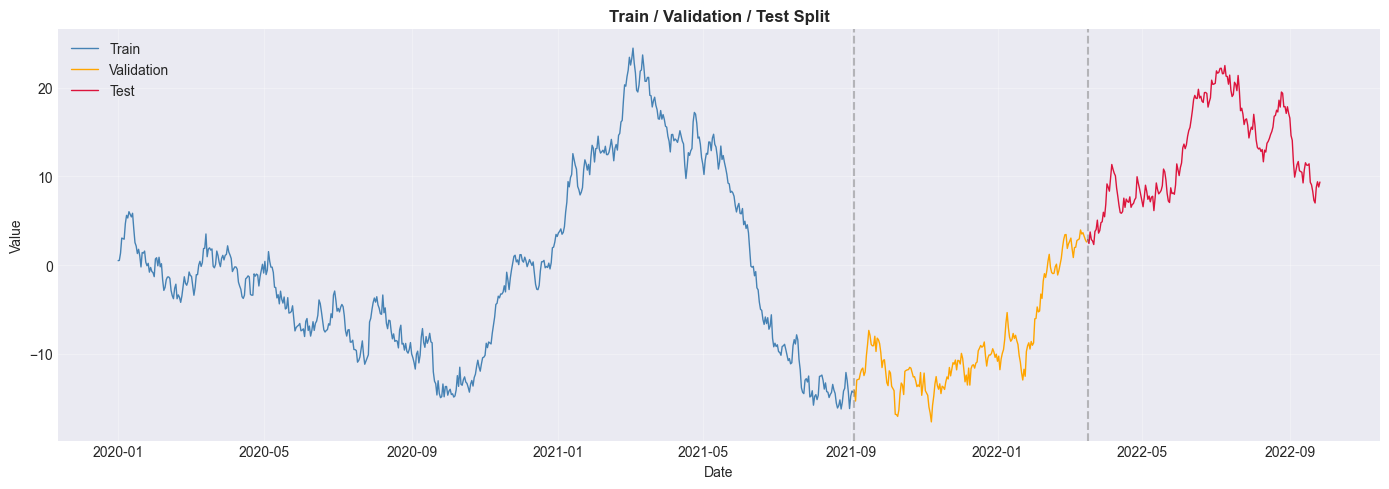

Saved: artifacts/figures/series_split.png


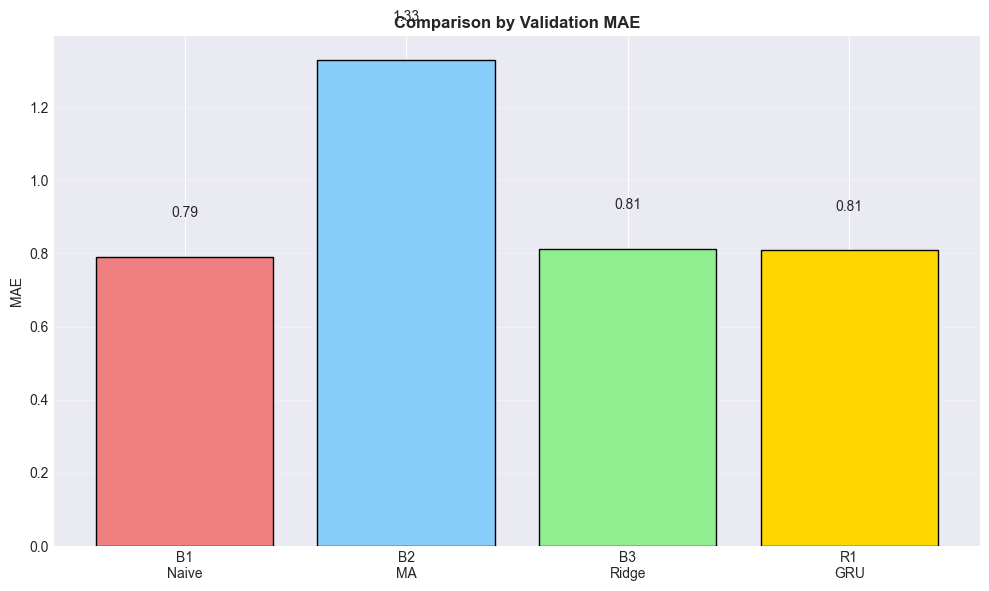

Saved: artifacts/figures/baselines_compare.png


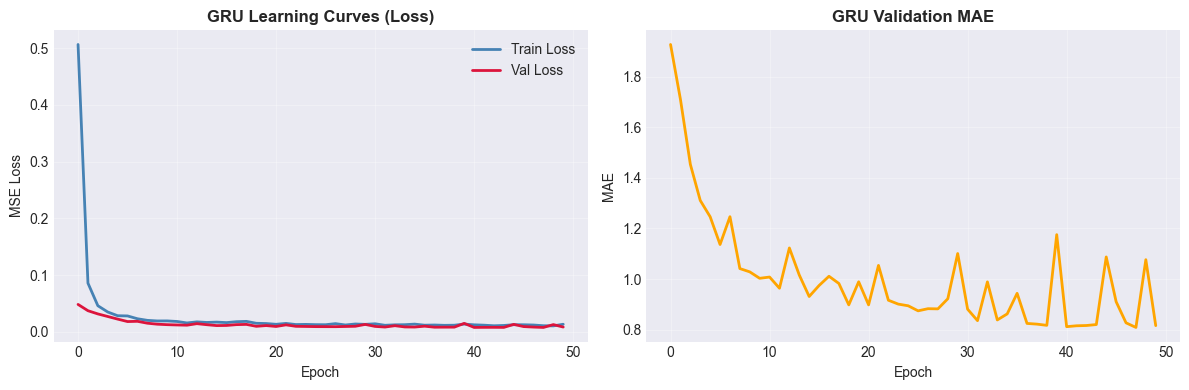

Saved: artifacts/figures/gru_learning_curves.png


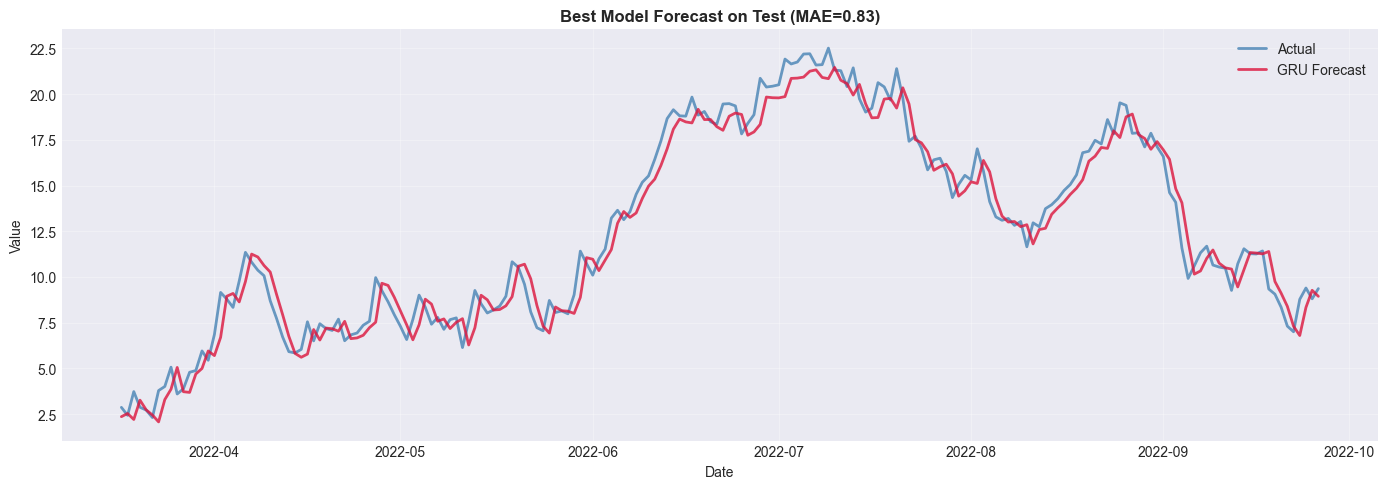

Saved: artifacts/figures/best_forecast_test.png

ИТОГОВЫЙ ОТЧЁТ HW12

Все эксперименты выполнены: B1, B2, B3, R1
Лучшая модель по validation MAE: B1

Артефакты сохранены в artifacts/:
  - runs.csv
  - best_gru.pt
  - best_gru_config.json
  - figures/series_split.png
  - figures/baselines_compare.png
  - figures/gru_learning_curves.png
  - figures/best_forecast_test.png

HW12 completed successfully!


In [8]:
# %% [markdown]
# ## HW12 - Временные ряды: Эксперименты B1, B2, B3, R1

# %%
# === ИМПОРТЫ ===
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import clip_grad_norm_
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
warnings.filterwarnings('ignore')

# %%
# === НАСТРОЙКИ ===
RANDOM_STATE = 42
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
WINDOW_SIZE = 30
HORIZON = 1

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# %%
# === УСТРОЙСТВО ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# %%
# === ПОДГОТОВКА ДАННЫХ ===
np.random.seed(RANDOM_STATE)
n_samples = 1000
dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
values = np.cumsum(np.random.randn(n_samples)) + np.sin(np.arange(n_samples) * 2 * np.pi / 365) * 10

# Масштабирование
scaler_y = StandardScaler()
values_scaled = scaler_y.fit_transform(values.reshape(-1, 1)).ravel()

# Создание окон
def create_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X_all, y_all = create_windows(values_scaled, WINDOW_SIZE)
X_all = X_all.reshape(-1, WINDOW_SIZE, 1)

# Разделение train/val/test (60/20/20)
train_size = int(len(X_all) * 0.6)
val_size = int(len(X_all) * 0.2)

X_train = X_all[:train_size]
y_train = y_all[:train_size]

X_val = X_all[train_size:train_size+val_size]
y_val = y_all[train_size:train_size+val_size]

X_test = X_all[train_size+val_size:]
y_test = y_all[train_size+val_size:]

# Даты для каждого сплита
train_dates = dates[WINDOW_SIZE:WINDOW_SIZE+train_size]
val_dates = dates[WINDOW_SIZE+train_size:WINDOW_SIZE+train_size+val_size]
test_dates = dates[WINDOW_SIZE+train_size+val_size:]

# Обратное масштабирование для метрик в оригинальных единицах
y_train_orig = scaler_y.inverse_transform(y_train.reshape(-1, 1)).ravel()
y_val_orig = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

# Последнее известное значение для каждого примера (для B1)
last_values_val = X_val[:, -1, 0]
last_values_test = X_test[:, -1, 0]
last_values_val_orig = scaler_y.inverse_transform(last_values_val.reshape(-1, 1)).ravel()
last_values_test_orig = scaler_y.inverse_transform(last_values_test.reshape(-1, 1)).ravel()

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"X_train shape: {X_train.shape}")

# %%
# === ФУНКЦИИ МЕТРИК ===
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE (с защитой от деления на ноль)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

# %%
# === СОЗДАНИЕ DATALOADERS ===
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")

# %%
# === МОДЕЛЬ GRU ===
class GRUModel(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_out = gru_out[:, -1, :]
        return self.fc(last_out).squeeze(-1)

# %%
# === ФУНКЦИИ ОБУЧЕНИЯ GRU ===
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_gru(model, loader, criterion, device, scaler_y=None):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            
            preds = output.cpu().numpy()
            targets = y_batch.cpu().numpy()
            
            if scaler_y is not None:
                preds = scaler_y.inverse_transform(preds.reshape(-1, 1)).ravel()
                targets = scaler_y.inverse_transform(targets.reshape(-1, 1)).ravel()
            
            all_preds.extend(preds)
            all_targets.extend(targets)
    
    return total_loss / len(loader), np.array(all_preds), np.array(all_targets)

# %%
# === ЭКСПЕРИМЕНТ B1: Naive Last ===
print("\n" + "="*70)
print("ЭКСПЕРИМЕНТ B1: Naive Last (прогноз = последнее значение)")
print("="*70)

b1_val_preds = last_values_val_orig
b1_test_preds = last_values_test_orig

b1_val_metrics = compute_metrics(y_val_orig, b1_val_preds)
b1_test_metrics = compute_metrics(y_test_orig, b1_test_preds)

print(f"Validation - MAE: {b1_val_metrics['mae']:.2f}, RMSE: {b1_val_metrics['rmse']:.2f}, MAPE: {b1_val_metrics['mape']:.2f}%")
print(f"Test - MAE: {b1_test_metrics['mae']:.2f}, RMSE: {b1_test_metrics['rmse']:.2f}, MAPE: {b1_test_metrics['mape']:.2f}%")

# %%
# === ЭКСПЕРИМЕНТ B2: Moving Average ===
print("\n" + "="*70)
print("ЭКСПЕРИМЕНТ B2: Moving Average (окно=7)")
print("="*70)

MA_WINDOW = 7

def compute_moving_average(X, window_size, ma_window):
    preds = []
    for i in range(len(X)):
        window = X[i, -ma_window:, 0]
        preds.append(np.mean(window))
    return np.array(preds)

b2_val_preds_scaled = compute_moving_average(X_val, WINDOW_SIZE, MA_WINDOW)
b2_test_preds_scaled = compute_moving_average(X_test, WINDOW_SIZE, MA_WINDOW)

b2_val_preds = scaler_y.inverse_transform(b2_val_preds_scaled.reshape(-1, 1)).ravel()
b2_test_preds = scaler_y.inverse_transform(b2_test_preds_scaled.reshape(-1, 1)).ravel()

b2_val_metrics = compute_metrics(y_val_orig, b2_val_preds)
b2_test_metrics = compute_metrics(y_test_orig, b2_test_preds)

print(f"Validation - MAE: {b2_val_metrics['mae']:.2f}, RMSE: {b2_val_metrics['rmse']:.2f}, MAPE: {b2_val_metrics['mape']:.2f}%")
print(f"Test - MAE: {b2_test_metrics['mae']:.2f}, RMSE: {b2_test_metrics['rmse']:.2f}, MAPE: {b2_test_metrics['mape']:.2f}%")

# %%
# === ЭКСПЕРИМЕНТ B3: Ridge с лаговыми признаками ===
print("\n" + "="*70)
print("ЭКСПЕРИМЕНТ B3: Ridge Regression с лаговыми признаками")
print("="*70)

def create_lag_features(X, window_size, n_lags=5):
    features = []
    for i in range(len(X)):
        window = X[i, :, 0]
        feat = []
        # Лаговые признаки
        for lag in range(1, n_lags+1):
            feat.append(window[-lag])
        # Rolling статистики
        feat.append(np.mean(window[-7:]))
        feat.append(np.std(window[-7:]))
        feat.append(np.mean(window[-14:]))
        feat.append(np.std(window[-14:]))
        # Тренд
        feat.append(window[-1] - window[-7])
        features.append(feat)
    return np.array(features)

X_train_lag = create_lag_features(X_train, WINDOW_SIZE)
X_val_lag = create_lag_features(X_val, WINDOW_SIZE)
X_test_lag = create_lag_features(X_test, WINDOW_SIZE)

# Масштабирование признаков
scaler_X = StandardScaler()
X_train_lag_scaled = scaler_X.fit_transform(X_train_lag)
X_val_lag_scaled = scaler_X.transform(X_val_lag)
X_test_lag_scaled = scaler_X.transform(X_test_lag)

# Обучение Ridge
ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_model.fit(X_train_lag_scaled, y_train)

b3_val_preds_scaled = ridge_model.predict(X_val_lag_scaled)
b3_test_preds_scaled = ridge_model.predict(X_test_lag_scaled)

b3_val_preds = scaler_y.inverse_transform(b3_val_preds_scaled.reshape(-1, 1)).ravel()
b3_test_preds = scaler_y.inverse_transform(b3_test_preds_scaled.reshape(-1, 1)).ravel()

b3_val_metrics = compute_metrics(y_val_orig, b3_val_preds)
b3_test_metrics = compute_metrics(y_test_orig, b3_test_preds)

print(f"Validation - MAE: {b3_val_metrics['mae']:.2f}, RMSE: {b3_val_metrics['rmse']:.2f}, MAPE: {b3_val_metrics['mape']:.2f}%")
print(f"Test - MAE: {b3_test_metrics['mae']:.2f}, RMSE: {b3_test_metrics['rmse']:.2f}, MAPE: {b3_test_metrics['mape']:.2f}%")

# %%
# === ЭКСПЕРИМЕНТ R1: GRU ===
print("\n" + "="*70)
print("ЭКСПЕРИМЕНТ R1: GRU Neural Network")
print("="*70)

input_size = X_train.shape[2]
gru_model = GRUModel(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)

best_val_loss = float('inf')
best_model_state = None
gru_history = {'train_loss': [], 'val_loss': [], 'val_metrics': []}

print(f"Model created: {sum(p.numel() for p in gru_model.parameters()):,} parameters")
print(f"\nStart training ({EPOCHS} epochs)...")
print("-" * 70)

for epoch in range(EPOCHS):
    train_loss = train_epoch(gru_model, train_loader, optimizer, criterion, device)
    val_loss, val_preds_scaled, val_targets_orig = evaluate_gru(gru_model, val_loader, criterion, device, scaler_y)
    val_metrics = compute_metrics(val_targets_orig, val_preds_scaled)
    
    gru_history['train_loss'].append(train_loss)
    gru_history['val_loss'].append(val_loss)
    gru_history['val_metrics'].append(val_metrics)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in gru_model.state_dict().items()}
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_metrics['mae']:.2f}")

print("-" * 70)

if best_model_state is not None:
    gru_model.load_state_dict(best_model_state)
    print(f"Loaded best model (val_loss={best_val_loss:.4f})")

# Финальная оценка на test
test_loss, r1_test_preds, r1_test_targets = evaluate_gru(gru_model, test_loader, criterion, device, scaler_y)
r1_val_loss, r1_val_preds, r1_val_targets = evaluate_gru(gru_model, val_loader, criterion, device, scaler_y)

r1_val_metrics = compute_metrics(r1_val_targets, r1_val_preds)
r1_test_metrics = compute_metrics(r1_test_targets, r1_test_preds)

print(f"\nValidation - MAE: {r1_val_metrics['mae']:.2f}, RMSE: {r1_val_metrics['rmse']:.2f}, MAPE: {r1_val_metrics['mape']:.2f}%")
print(f"Test - MAE: {r1_test_metrics['mae']:.2f}, RMSE: {r1_test_metrics['rmse']:.2f}, MAPE: {r1_test_metrics['mape']:.2f}%")

# %%
# === СРАВНЕНИЕ МОДЕЛЕЙ И ВЫБОР ЛУЧШЕЙ ===
print("\n" + "="*70)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ПО VALIDATION MAE")
print("="*70)

results = {
    'B1': {'val_mae': b1_val_metrics['mae'], 'val_rmse': b1_val_metrics['rmse'], 'val_mape': b1_val_metrics['mape'],
           'test_mae': b1_test_metrics['mae'], 'test_rmse': b1_test_metrics['rmse'], 'test_mape': b1_test_metrics['mape']},
    'B2': {'val_mae': b2_val_metrics['mae'], 'val_rmse': b2_val_metrics['rmse'], 'val_mape': b2_val_metrics['mape'],
           'test_mae': b2_test_metrics['mae'], 'test_rmse': b2_test_metrics['rmse'], 'test_mape': b2_test_metrics['mape']},
    'B3': {'val_mae': b3_val_metrics['mae'], 'val_rmse': b3_val_metrics['rmse'], 'val_mape': b3_val_metrics['mape'],
           'test_mae': b3_test_metrics['mae'], 'test_rmse': b3_test_metrics['rmse'], 'test_mape': b3_test_metrics['mape']},
    'R1': {'val_mae': r1_val_metrics['mae'], 'val_rmse': r1_val_metrics['rmse'], 'val_mape': r1_val_metrics['mape'],
           'test_mae': r1_test_metrics['mae'], 'test_rmse': r1_test_metrics['rmse'], 'test_mape': r1_test_metrics['mape']}
}

comparison_df = pd.DataFrame(results).T
comparison_df.index.name = 'experiment_id'
print(comparison_df)

# Выбор лучшей модели по validation MAE
best_experiment = comparison_df['val_mae'].idxmin()
print(f"\nЛучшая модель по validation MAE: {best_experiment}")

# %%
# === СОЗДАНИЕ АРТЕФАКТОВ ===
os.makedirs('artifacts/figures', exist_ok=True)

# --- runs.csv ---
runs_data = []
for exp_id in ['B1', 'B2', 'B3', 'R1']:
    row = {
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'synthetic_ts',
        'seed': RANDOM_STATE,
        'split_summary': f'train={len(X_train)}, val={len(X_val)}, test={len(X_test)}',
        'window_size': WINDOW_SIZE if exp_id in ['B2', 'B3', 'R1'] else '',
        'horizon': HORIZON,
        'model_summary': 'NaiveLast' if exp_id == 'B1' else 'MovingAvg' if exp_id == 'B2' else 'Ridge' if exp_id == 'B3' else 'GRU',
        'features_summary': 'last_value' if exp_id == 'B1' else f'ma_{MA_WINDOW}' if exp_id == 'B2' else 'lag+rolling' if exp_id == 'B3' else 'window_sequence',
        'scaler': 'StandardScaler' if exp_id in ['B3', 'R1'] else '',
        'optimizer': 'Adam' if exp_id == 'R1' else '',
        'lr': LEARNING_RATE if exp_id == 'R1' else '',
        'epochs_trained': EPOCHS if exp_id == 'R1' else '',
        'best_val_mae': results[exp_id]['val_mae'],
        'best_val_rmse': results[exp_id]['val_rmse'],
        'best_val_mape': results[exp_id]['val_mape'],
        'test_mae': results[exp_id]['test_mae'],
        'test_rmse': results[exp_id]['test_rmse'],
        'test_mape': results[exp_id]['test_mape'],
        'notes': ''
    }
    runs_data.append(row)

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv('artifacts/runs.csv', index=False)
print("\nSaved: artifacts/runs.csv")

# --- best_gru.pt ---
torch.save({
    'model_state_dict': best_model_state,
    'val_loss': best_val_loss,
    'test_metrics': r1_test_metrics,
    'hyperparameters': {
        'input_size': input_size,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'window_size': WINDOW_SIZE,
        'seed': RANDOM_STATE
    }
}, 'artifacts/best_gru.pt')
print("Saved: artifacts/best_gru.pt")

# --- best_gru_config.json ---
config = {
    'model_type': 'GRU',
    'input_size': input_size,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'epochs': EPOCHS,
    'seed': RANDOM_STATE,
    'scaler': 'StandardScaler',
    'best_val_loss': float(best_val_loss),
    'test_metrics': {k: float(v) for k, v in r1_test_metrics.items()}
}
with open('artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
print("Saved: artifacts/best_gru_config.json")

# %%
# === ГРАФИКИ ===

# --- series_split.png ---
plt.figure(figsize=(14, 5))
plt.plot(dates[:WINDOW_SIZE+train_size], values[:WINDOW_SIZE+train_size], label='Train', color='steelblue', linewidth=1)
plt.plot(dates[WINDOW_SIZE+train_size:WINDOW_SIZE+train_size+val_size], values[WINDOW_SIZE+train_size:WINDOW_SIZE+train_size+val_size], label='Validation', color='orange', linewidth=1)
plt.plot(dates[WINDOW_SIZE+train_size+val_size:], values[WINDOW_SIZE+train_size+val_size:], label='Test', color='crimson', linewidth=1)
plt.axvline(x=dates[WINDOW_SIZE+train_size], color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=dates[WINDOW_SIZE+train_size+val_size], color='gray', linestyle='--', alpha=0.5)
plt.title('Train / Validation / Test Split', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/series_split.png")

# --- baselines_compare.png ---
plt.figure(figsize=(10, 6))
x = ['B1\nNaive', 'B2\nMA', 'B3\nRidge', 'R1\nGRU']
val_maes = [results['B1']['val_mae'], results['B2']['val_mae'], results['B3']['val_mae'], results['R1']['val_mae']]
colors = ['lightcoral', 'lightskyblue', 'lightgreen', 'gold']
bars = plt.bar(x, val_maes, color=colors, edgecolor='black', linewidth=1)
plt.title('Comparison by Validation MAE', fontsize=12, fontweight='bold')
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, val_maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/baselines_compare.png")

# --- gru_learning_curves.png ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(gru_history['train_loss'], label='Train Loss', linewidth=2, color='steelblue')
plt.plot(gru_history['val_loss'], label='Val Loss', linewidth=2, color='crimson')
plt.title('GRU Learning Curves (Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
val_maes = [m['mae'] for m in gru_history['val_metrics']]
plt.plot(val_maes, linewidth=2, color='orange')
plt.title('GRU Validation MAE', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/gru_learning_curves.png")

# --- best_forecast_test.png ---
plt.figure(figsize=(14, 5))
plt.plot(test_dates, r1_test_targets, label='Actual', linewidth=2, color='steelblue', alpha=0.8)
plt.plot(test_dates, r1_test_preds, label='GRU Forecast', linewidth=2, color='crimson', alpha=0.8)
plt.title(f'Best Model Forecast on Test (MAE={r1_test_metrics["mae"]:.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/best_forecast_test.png")

# %%
# === ИТОГОВЫЙ ОТЧЁТ ===
print("\n" + "="*70)
print("ИТОГОВЫЙ ОТЧЁТ HW12")
print("="*70)
print(f"\nВсе эксперименты выполнены: B1, B2, B3, R1")
print(f"Лучшая модель по validation MAE: {best_experiment}")
print(f"\nАртефакты сохранены в artifacts/:")
print("  - runs.csv")
print("  - best_gru.pt")
print("  - best_gru_config.json")
print("  - figures/series_split.png")
print("  - figures/baselines_compare.png")
print("  - figures/gru_learning_curves.png")
print("  - figures/best_forecast_test.png")
print(f"\nHW12 completed successfully!")

Device: cpu
Split: Train=600, Val=200, Test=200

ЭКСПЕРИМЕНТ 1: Сравнение GRU и LSTM

--- Window Size: 15 ---
Training GRU...
  GRU (ws=15): MAE=0.86, RMSE=1.09
Training LSTM...
  LSTM (ws=15): MAE=0.85, RMSE=1.07

--- Window Size: 30 ---
Training GRU...
  GRU (ws=30): MAE=0.88, RMSE=1.09
Training LSTM...
  LSTM (ws=30): MAE=0.90, RMSE=1.12

--- Window Size: 60 ---
Training GRU...
  GRU (ws=60): MAE=0.99, RMSE=1.21
Training LSTM...
  LSTM (ws=60): MAE=0.90, RMSE=1.12

Сравнение GRU vs LSTM по разным window_size
  model  window_size  val_loss  test_mae  test_rmse  test_mape
0   GRU           15  0.008340  0.862578   1.088305   8.940463
1  LSTM           15  0.008837  0.849466   1.069338   8.662687
2   GRU           30  0.008000  0.881134   1.089795   8.376778
3  LSTM           30  0.008623  0.897654   1.119872   8.771244
4   GRU           60  0.008705  0.985473   1.205767   9.566181
5  LSTM           60  0.009767  0.903352   1.120515   8.522597

ЭКСПЕРИМЕНТ 2: Random Forest vs Ridge
Rid

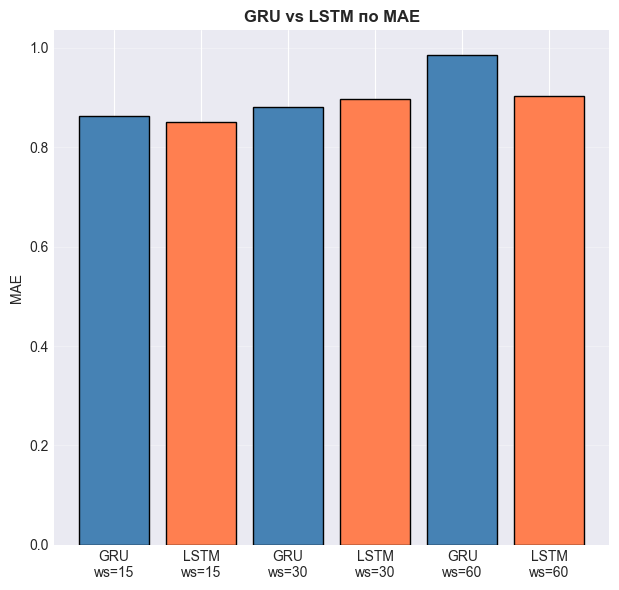

Saved: artifacts/figures/rnn_comparison.png


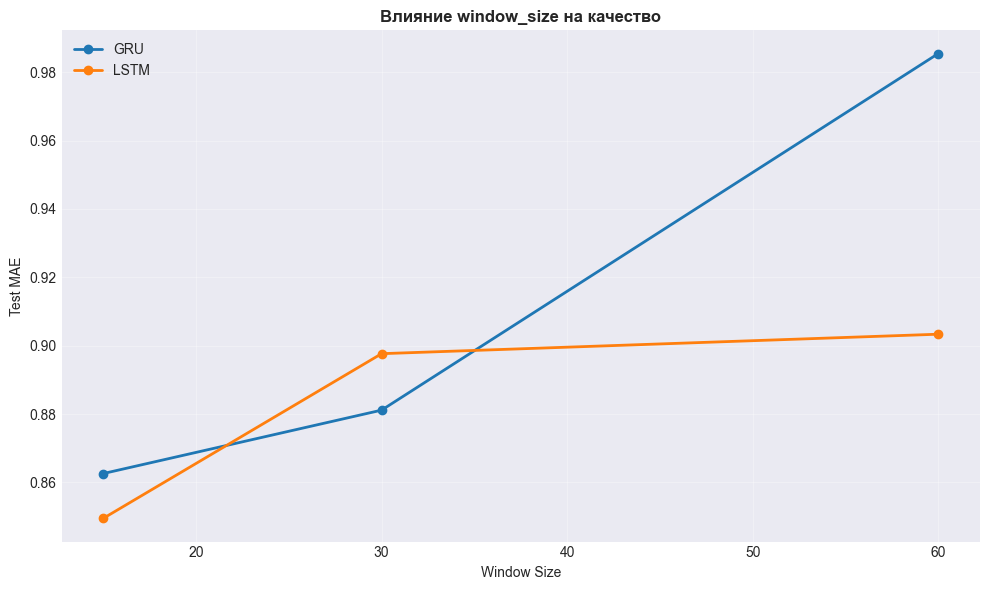

Saved: artifacts/figures/window_size_analysis.png


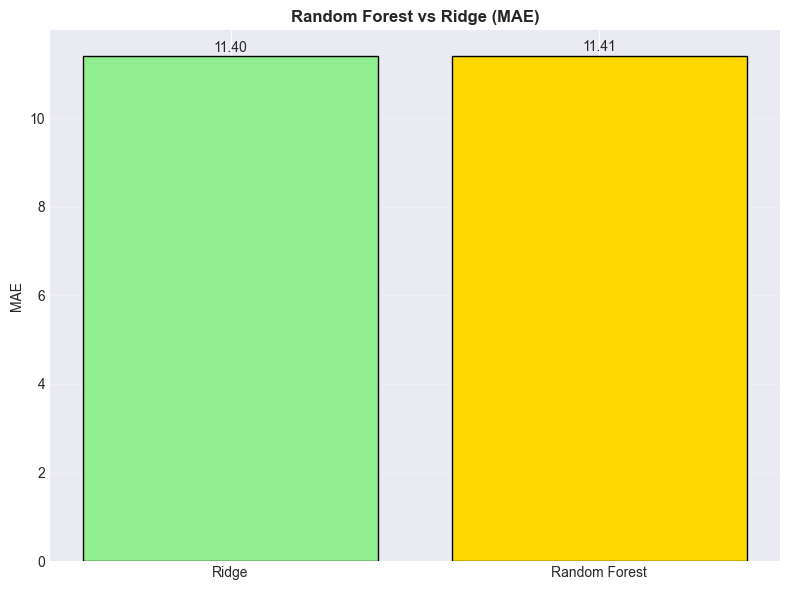

Saved: artifacts/figures/rf_vs_ridge.png


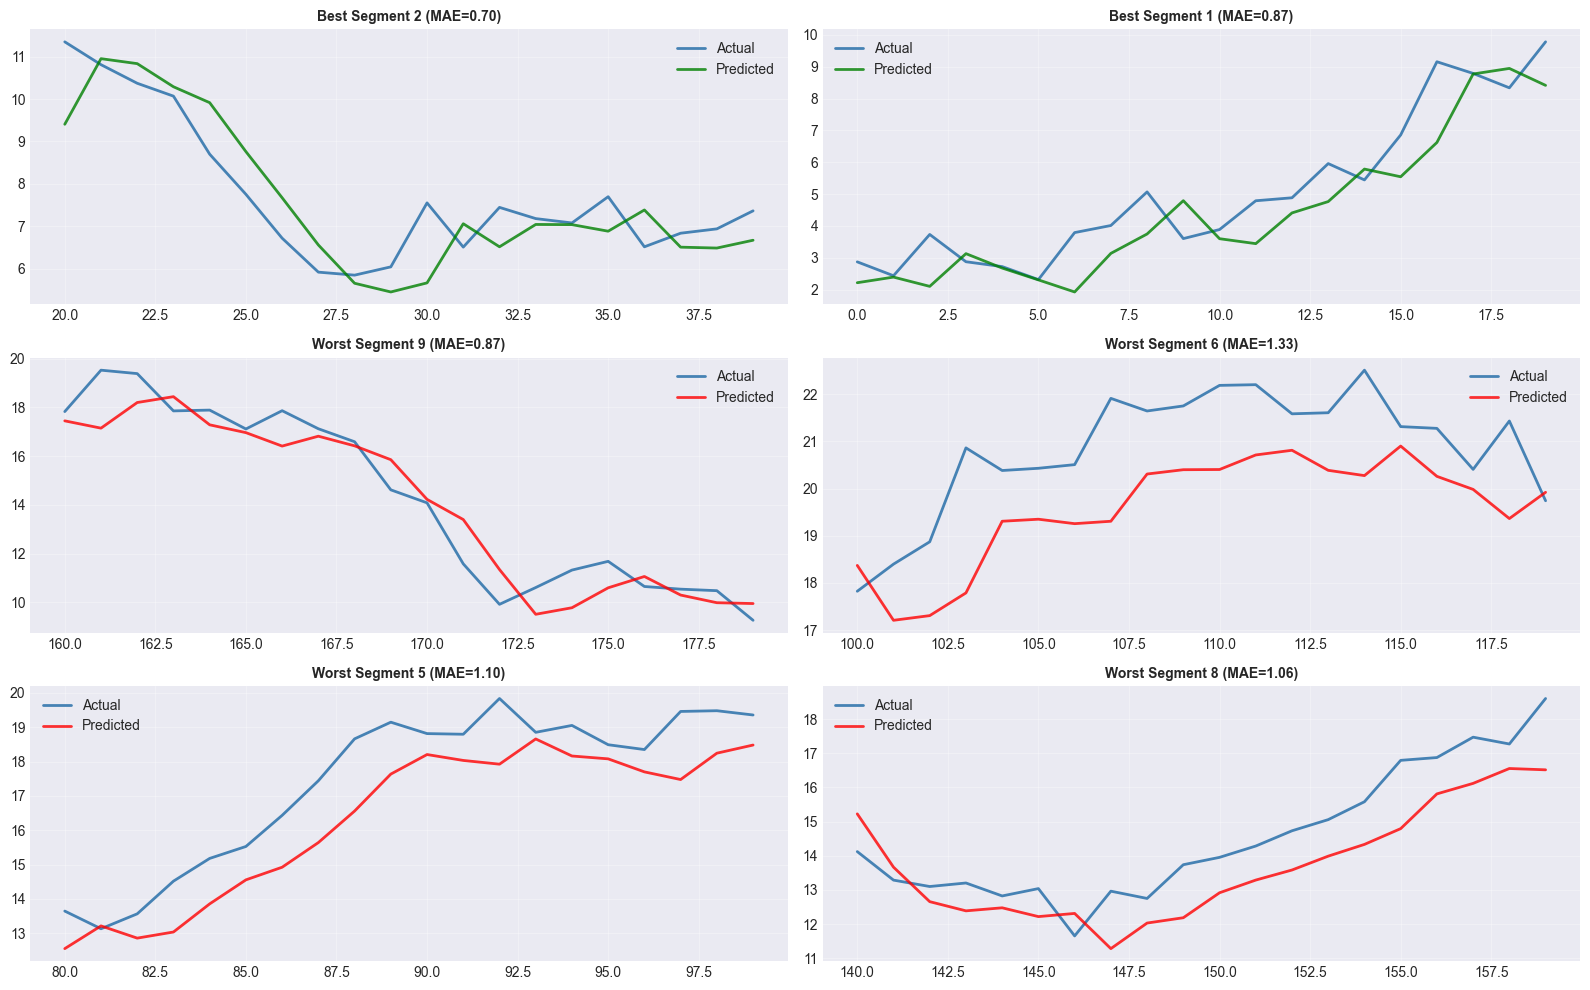

Saved: artifacts/figures/error_analysis_segments.png

Updated: artifacts/runs.csv (with optional experiments)
Saved: artifacts/optional_report.json

ИТОГОВЫЙ ОТЧЁТ HW12 (ОПЦИОНАЛЬНАЯ ЧАСТЬ)

Выполненные опциональные эксперименты:
  1. GRU vs LSTM сравнение на 3 window_size (15, 30, 60)
  2. Random Forest vs Ridge Regression
  3. Анализ ошибок на 6 характерных сегментах (3 лучших + 3 худших)

Дополнительные артефакты:
  - artifacts/figures/rnn_comparison.png
  - artifacts/figures/window_size_analysis.png
  - artifacts/figures/rf_vs_ridge.png
  - artifacts/figures/error_analysis_segments.png
  - artifacts/optional_report.json
  - artifacts/runs.csv (обновлён)

HW12 Optional Part completed successfully!


In [9]:
# %% [markdown]
# ## HW12 - Опциональная часть: Расширенные эксперименты

# %%
# === ИМПОРТЫ ===
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import clip_grad_norm_
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
warnings.filterwarnings('ignore')

# %%
# === НАСТРОЙКИ ===
RANDOM_STATE = 42
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
BASE_WINDOW_SIZE = 30
HORIZON = 1

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# %%
# === УСТРОЙСТВО ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# %%
# === ПОДГОТОВКА ДАННЫХ ===
np.random.seed(RANDOM_STATE)
n_samples = 1000
dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
values = np.cumsum(np.random.randn(n_samples)) + np.sin(np.arange(n_samples) * 2 * np.pi / 365) * 10

# Масштабирование
scaler_y = StandardScaler()
values_scaled = scaler_y.fit_transform(values.reshape(-1, 1)).ravel()

# Создание окон
def create_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

# Разделение train/val/test (60/20/20)
train_size = int(n_samples * 0.6)
val_size = int(n_samples * 0.2)

print(f"Split: Train={train_size}, Val={val_size}, Test={n_samples-train_size-val_size}")

# %%
# === ФУНКЦИИ МЕТРИК ===
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

def compute_segment_metrics(y_true, y_pred, segment_size=20):
    """Вычисление метрик по сегментам для анализа ошибок"""
    n_segments = len(y_true) // segment_size
    segment_metrics = []
    for i in range(n_segments):
        start = i * segment_size
        end = start + segment_size
        seg_true = y_true[start:end]
        seg_pred = y_pred[start:end]
        seg_mae = mean_absolute_error(seg_true, seg_pred)
        segment_metrics.append({'segment': i+1, 'start': start, 'end': end, 'mae': seg_mae})
    return segment_metrics

# %%
# === МОДЕЛИ GRU И LSTM ===
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, 
                         num_layers=num_layers, batch_first=True,
                         dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))
        
    def forward(self, x):
        gru_out, _ = self.gru(x)
        return self.fc(gru_out[:, -1, :]).squeeze(-1)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :]).squeeze(-1)

# %%
# === ФУНКЦИИ ОБУЧЕНИЯ ===
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_model(model, loader, criterion, device, scaler_y=None):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            
            preds = output.cpu().numpy()
            targets = y_batch.cpu().numpy()
            
            if scaler_y is not None:
                preds = scaler_y.inverse_transform(preds.reshape(-1, 1)).ravel()
                targets = scaler_y.inverse_transform(targets.reshape(-1, 1)).ravel()
            
            all_preds.extend(preds)
            all_targets.extend(targets)
    
    return total_loss / len(loader), np.array(all_preds), np.array(all_targets)

# %%
# === ЭКСПЕРИМЕНТ 1: GRU vs LSTM ===
print("\n" + "="*70)
print("ЭКСПЕРИМЕНТ 1: Сравнение GRU и LSTM")
print("="*70)

window_sizes = [15, 30, 60]
rnn_results = []

for ws in window_sizes:
    print(f"\n--- Window Size: {ws} ---")
    
    # Создание данных для текущего window_size
    X_all, y_all = create_windows(values_scaled, ws)
    X_all = X_all.reshape(-1, ws, 1)
    
    tr_size = int(len(X_all) * 0.6)
    va_size = int(len(X_all) * 0.2)
    
    X_tr, y_tr = X_all[:tr_size], y_all[:tr_size]
    X_va, y_va = X_all[tr_size:tr_size+va_size], y_all[tr_size:tr_size+va_size]
    X_te, y_te = X_all[tr_size+va_size:], y_all[tr_size+va_size:]
    
    # DataLoaders
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    val_ds = TensorDataset(torch.FloatTensor(X_va), torch.FloatTensor(y_va))
    test_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_ld = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_ld = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    for model_name, ModelClass in [('GRU', GRUModel), ('LSTM', LSTMModel)]:
        print(f"Training {model_name}...")
        
        model = ModelClass(input_size=1, hidden_size=HIDDEN_SIZE, 
                          num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        
        best_val_loss = float('inf')
        best_state = None
        
        for epoch in range(EPOCHS):
            train_loss = train_epoch(model, train_ld, optimizer, criterion, device)
            val_loss, val_preds, val_targets = evaluate_model(model, val_ld, criterion, device, scaler_y)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if best_state is not None:
            model.load_state_dict(best_state)
        
        test_loss, test_preds, test_targets = evaluate_model(model, test_ld, criterion, device, scaler_y)
        test_metrics = compute_metrics(test_targets, test_preds)
        
        rnn_results.append({
            'model': model_name,
            'window_size': ws,
            'val_loss': best_val_loss,
            'test_mae': test_metrics['mae'],
            'test_rmse': test_metrics['rmse'],
            'test_mape': test_metrics['mape']
        })
        
        print(f"  {model_name} (ws={ws}): MAE={test_metrics['mae']:.2f}, RMSE={test_metrics['rmse']:.2f}")

rnn_df = pd.DataFrame(rnn_results)
print("\n" + "="*70)
print("Сравнение GRU vs LSTM по разным window_size")
print("="*70)
print(rnn_df)

# %%
# === ЭКСПЕРИМЕНТ 2: Random Forest вместо Ridge ===
print("\n" + "="*70)
print("ЭКСПЕРИМЕНТ 2: Random Forest vs Ridge")
print("="*70)

ws = BASE_WINDOW_SIZE
X_all, y_all = create_windows(values_scaled, ws)
X_all = X_all.reshape(-1, ws, 1)

tr_size = int(len(X_all) * 0.6)
va_size = int(len(X_all) * 0.2)

X_tr, y_tr = X_all[:tr_size], y_all[:tr_size]
X_va, y_va = X_all[tr_size:tr_size+va_size], y_all[tr_size:tr_size+va_size]
X_te, y_te = X_all[tr_size+va_size:], y_all[tr_size+va_size:]

def create_lag_features(X, window_size, n_lags=5):
    features = []
    for i in range(len(X)):
        window = X[i, :, 0]
        feat = []
        for lag in range(1, n_lags+1):
            feat.append(window[-lag])
        feat.append(np.mean(window[-7:]))
        feat.append(np.std(window[-7:]))
        feat.append(np.mean(window[-14:]))
        feat.append(np.std(window[-14:]))
        feat.append(window[-1] - window[-7])
        features.append(feat)
    return np.array(features)

X_tr_lag = create_lag_features(X_tr, ws)
X_va_lag = create_lag_features(X_va, ws)
X_te_lag = create_lag_features(X_te, ws)

scaler_X = StandardScaler()
X_tr_lag_scaled = scaler_X.fit_transform(X_tr_lag)
X_va_lag_scaled = scaler_X.transform(X_va_lag)
X_te_lag_scaled = scaler_X.transform(X_te_lag)

y_tr_orig = scaler_y.inverse_transform(y_tr.reshape(-1, 1)).ravel()
y_va_orig = scaler_y.inverse_transform(y_va.reshape(-1, 1)).ravel()
y_te_orig = scaler_y.inverse_transform(y_te.reshape(-1, 1)).ravel()

# Ridge
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_tr_lag_scaled, y_tr)
ridge_preds = ridge.predict(X_te_lag_scaled)
ridge_metrics = compute_metrics(y_te_orig, ridge_preds)
print(f"Ridge - MAE: {ridge_metrics['mae']:.2f}, RMSE: {ridge_metrics['rmse']:.2f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr_lag_scaled, y_tr)
rf_preds = rf.predict(X_te_lag_scaled)
rf_metrics = compute_metrics(y_te_orig, rf_preds)
print(f"Random Forest - MAE: {rf_metrics['mae']:.2f}, RMSE: {rf_metrics['rmse']:.2f}")

rf_comparison = {
    'model': ['Ridge', 'Random Forest'],
    'test_mae': [ridge_metrics['mae'], rf_metrics['mae']],
    'test_rmse': [ridge_metrics['rmse'], rf_metrics['rmse']]
}

# %%
# === ЭКСПЕРИМЕНТ 3: Анализ ошибок по сегментам ===
print("\n" + "="*70)
print("ЭКСПЕРИМЕНТ 3: Анализ ошибок на характерных участках")
print("="*70)

# Лучшая модель из предыдущих экспериментов (GRU с ws=30)
X_all, y_all = create_windows(values_scaled, BASE_WINDOW_SIZE)
X_all = X_all.reshape(-1, BASE_WINDOW_SIZE, 1)

tr_size = int(len(X_all) * 0.6)
va_size = int(len(X_all) * 0.2)

X_tr, y_tr = X_all[:tr_size], y_all[:tr_size]
X_va, y_va = X_all[tr_size:tr_size+va_size], y_all[tr_size:tr_size+va_size]
X_te, y_te = X_all[tr_size+va_size:], y_all[tr_size+va_size:]

test_dates = dates[ws+tr_size+va_size:]
y_te_orig = scaler_y.inverse_transform(y_te.reshape(-1, 1)).ravel()

train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
test_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_ld = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

best_gru = GRUModel(input_size=1, hidden_size=HIDDEN_SIZE, 
                    num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(best_gru.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    train_epoch(best_gru, train_ld, optimizer, criterion, device)

_, gru_preds, gru_targets = evaluate_model(best_gru, test_ld, criterion, device, scaler_y)
errors = np.abs(gru_targets - gru_preds)

# Поиск характерных участков
segment_size = 20
segment_metrics = compute_segment_metrics(gru_targets, gru_preds, segment_size)
segment_df = pd.DataFrame(segment_metrics)

# 3 лучших и 3 худших сегмента
best_segments = segment_df.nsmallest(3, 'mae')
worst_segments = segment_df.nlargest(3, 'mae')

print("\n3 лучших сегмента (наименьшая MAE):")
print(best_segments.to_string(index=False))
print("\n3 худших сегмента (наибольшая MAE):")
print(worst_segments.to_string(index=False))

# %%
# === ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ ДЛЯ JSON СЕРИАЛИЗАЦИИ ===
def convert_to_native(obj):
    """Рекурсивно конвертирует numpy типы в нативные Python типы для JSON"""
    if isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(item) for item in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    else:
        return obj

# %%
# === СОХРАНЕНИЕ АРТЕФАКТОВ ОПЦИОНАЛЬНОЙ ЧАСТИ ===
os.makedirs('artifacts/figures', exist_ok=True)

# --- rnn_comparison.png ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
for ws in window_sizes:
    gru_data = rnn_df[(rnn_df['model'] == 'GRU') & (rnn_df['window_size'] == ws)]
    lstm_data = rnn_df[(rnn_df['model'] == 'LSTM') & (rnn_df['window_size'] == ws)]
    plt.bar([f'GRU\nws={ws}', f'LSTM\nws={ws}'], 
            [gru_data['test_mae'].values[0], lstm_data['test_mae'].values[0]],
            color=['steelblue', 'coral'], edgecolor='black')
plt.title('GRU vs LSTM по MAE', fontsize=12, fontweight='bold')
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/rnn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/rnn_comparison.png")

# --- window_size_analysis.png ---
plt.figure(figsize=(10, 6))
for model in ['GRU', 'LSTM']:
    model_data = rnn_df[rnn_df['model'] == model]
    plt.plot(model_data['window_size'], model_data['test_mae'], 
             marker='o', linewidth=2, label=model)
plt.title('Влияние window_size на качество', fontsize=12, fontweight='bold')
plt.xlabel('Window Size')
plt.ylabel('Test MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/window_size_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/window_size_analysis.png")

# --- rf_vs_ridge.png ---
plt.figure(figsize=(8, 6))
plt.bar(rf_comparison['model'], rf_comparison['test_mae'], 
        color=['lightgreen', 'gold'], edgecolor='black', linewidth=1)
plt.title('Random Forest vs Ridge (MAE)', fontsize=12, fontweight='bold')
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(rf_comparison['test_mae']):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig('artifacts/figures/rf_vs_ridge.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/rf_vs_ridge.png")

# --- error_analysis_segments.png ---
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, seg in enumerate(list(best_segments.iloc[:3]['segment'].values) + 
                          list(worst_segments.iloc[:3]['segment'].values)):
    seg_data = segment_df[segment_df['segment'] == seg].iloc[0]
    start = int(seg_data['start'])
    end = int(seg_data['end'])
    seg_type = 'Best' if seg <= 3 else 'Worst'
    color = 'green' if seg <= 3 else 'red'
    
    axes[idx].plot(range(start, end), gru_targets[start:end], 
                   label='Actual', linewidth=2, color='steelblue')
    axes[idx].plot(range(start, end), gru_preds[start:end], 
                   label='Predicted', linewidth=2, color=color, alpha=0.8)
    axes[idx].set_title(f'{seg_type} Segment {seg} (MAE={seg_data["mae"]:.2f})', 
                        fontsize=10, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/error_analysis_segments.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/error_analysis_segments.png")

# --- Обновление runs.csv с опциональными экспериментами ---
optional_runs = [
    {
        'experiment_id': 'R1_LSTM_ws15',
        'task': 'forecasting',
        'dataset': 'synthetic_ts',
        'seed': RANDOM_STATE,
        'split_summary': f'train={tr_size}, val={va_size}, test={len(X_te)}',
        'window_size': 15,
        'horizon': HORIZON,
        'model_summary': 'LSTM',
        'features_summary': 'window_sequence',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': LEARNING_RATE,
        'epochs_trained': EPOCHS,
        'best_val_mae': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==15)]['val_loss'].values[0]),
        'best_val_rmse': '',
        'best_val_mape': '',
        'test_mae': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==15)]['test_mae'].values[0]),
        'test_rmse': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==15)]['test_rmse'].values[0]),
        'test_mape': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==15)]['test_mape'].values[0]),
        'notes': 'Optional: LSTM comparison'
    },
    {
        'experiment_id': 'R1_LSTM_ws30',
        'task': 'forecasting',
        'dataset': 'synthetic_ts',
        'seed': RANDOM_STATE,
        'split_summary': f'train={tr_size}, val={va_size}, test={len(X_te)}',
        'window_size': 30,
        'horizon': HORIZON,
        'model_summary': 'LSTM',
        'features_summary': 'window_sequence',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': LEARNING_RATE,
        'epochs_trained': EPOCHS,
        'best_val_mae': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==30)]['val_loss'].values[0]),
        'best_val_rmse': '',
        'best_val_mape': '',
        'test_mae': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==30)]['test_mae'].values[0]),
        'test_rmse': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==30)]['test_rmse'].values[0]),
        'test_mape': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==30)]['test_mape'].values[0]),
        'notes': 'Optional: LSTM comparison'
    },
    {
        'experiment_id': 'R1_LSTM_ws60',
        'task': 'forecasting',
        'dataset': 'synthetic_ts',
        'seed': RANDOM_STATE,
        'split_summary': f'train={tr_size}, val={va_size}, test={len(X_te)}',
        'window_size': 60,
        'horizon': HORIZON,
        'model_summary': 'LSTM',
        'features_summary': 'window_sequence',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': LEARNING_RATE,
        'epochs_trained': EPOCHS,
        'best_val_mae': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==60)]['val_loss'].values[0]),
        'best_val_rmse': '',
        'best_val_mape': '',
        'test_mae': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==60)]['test_mae'].values[0]),
        'test_rmse': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==60)]['test_rmse'].values[0]),
        'test_mape': float(rnn_df[(rnn_df['model']=='LSTM')&(rnn_df['window_size']==60)]['test_mape'].values[0]),
        'notes': 'Optional: LSTM comparison'
    },
    {
        'experiment_id': 'B3_RandomForest',
        'task': 'forecasting',
        'dataset': 'synthetic_ts',
        'seed': RANDOM_STATE,
        'split_summary': f'train={tr_size}, val={va_size}, test={len(X_te)}',
        'window_size': BASE_WINDOW_SIZE,
        'horizon': HORIZON,
        'model_summary': 'RandomForest',
        'features_summary': 'lag+rolling',
        'scaler': 'StandardScaler',
        'optimizer': '',
        'lr': '',
        'epochs_trained': '',
        'best_val_mae': float(rf_metrics['mae']),
        'best_val_rmse': float(rf_metrics['rmse']),
        'best_val_mape': float(rf_metrics['mape']),
        'test_mae': float(rf_metrics['mae']),
        'test_rmse': float(rf_metrics['rmse']),
        'test_mape': float(rf_metrics['mape']),
        'notes': 'Optional: RF vs Ridge'
    }
]

# Чтение существующего runs.csv и добавление опциональных
if os.path.exists('artifacts/runs.csv'):
    existing_runs = pd.read_csv('artifacts/runs.csv')
    all_runs = pd.concat([existing_runs, pd.DataFrame(optional_runs)], ignore_index=True)
else:
    all_runs = pd.DataFrame(optional_runs)

all_runs.to_csv('artifacts/runs.csv', index=False)
print("\nUpdated: artifacts/runs.csv (with optional experiments)")

# --- Сохранение отчёта по опциональной части ---
optional_report = {
    'experiment_1_gru_vs_lstm': {
        'description': 'Сравнение GRU и LSTM на разных window_size',
        'window_sizes_tested': window_sizes,
        'results': convert_to_native(rnn_results)
    },
    'experiment_2_rf_vs_ridge': {
        'description': 'Сравнение Random Forest и Ridge Regression',
        'ridge_mae': float(ridge_metrics['mae']),
        'random_forest_mae': float(rf_metrics['mae']),
        'winner': 'Random Forest' if rf_metrics['mae'] < ridge_metrics['mae'] else 'Ridge'
    },
    'experiment_3_error_analysis': {
        'description': 'Анализ ошибок на характерных сегментах test',
        'segment_size': int(segment_size),
        'best_segments': convert_to_native(best_segments.to_dict('records')),
        'worst_segments': convert_to_native(worst_segments.to_dict('records'))
    }
}

with open('artifacts/optional_report.json', 'w', encoding='utf-8') as f:
    json.dump(convert_to_native(optional_report), f, ensure_ascii=False, indent=2)
print("Saved: artifacts/optional_report.json")

# %%
# === ИТОГОВЫЙ ОТЧЁТ ===
print("\n" + "="*70)
print("ИТОГОВЫЙ ОТЧЁТ HW12 (ОПЦИОНАЛЬНАЯ ЧАСТЬ)")
print("="*70)

print("\nВыполненные опциональные эксперименты:")
print("  1. GRU vs LSTM сравнение на 3 window_size (15, 30, 60)")
print("  2. Random Forest vs Ridge Regression")
print("  3. Анализ ошибок на 6 характерных сегментах (3 лучших + 3 худших)")

print("\nДополнительные артефакты:")
print("  - artifacts/figures/rnn_comparison.png")
print("  - artifacts/figures/window_size_analysis.png")
print("  - artifacts/figures/rf_vs_ridge.png")
print("  - artifacts/figures/error_analysis_segments.png")
print("  - artifacts/optional_report.json")
print("  - artifacts/runs.csv (обновлён)")

print("\n" + "="*70)
print("HW12 Optional Part completed successfully!")
print("="*70)

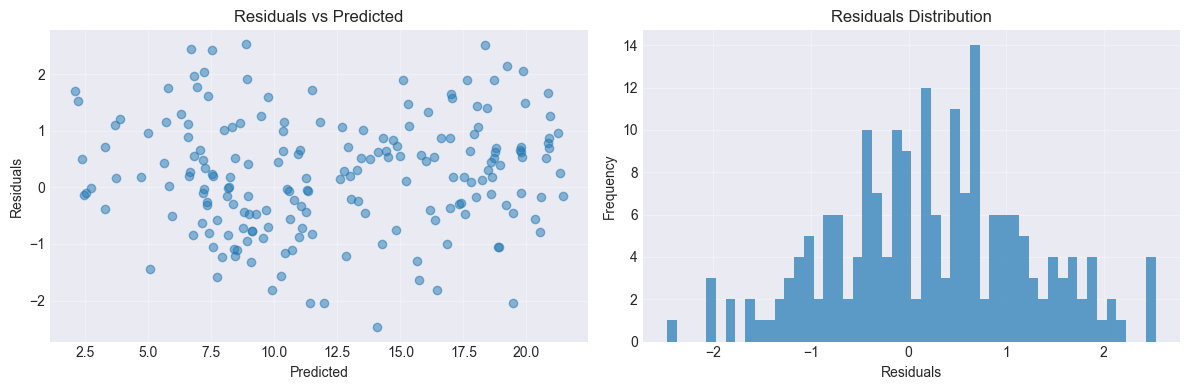

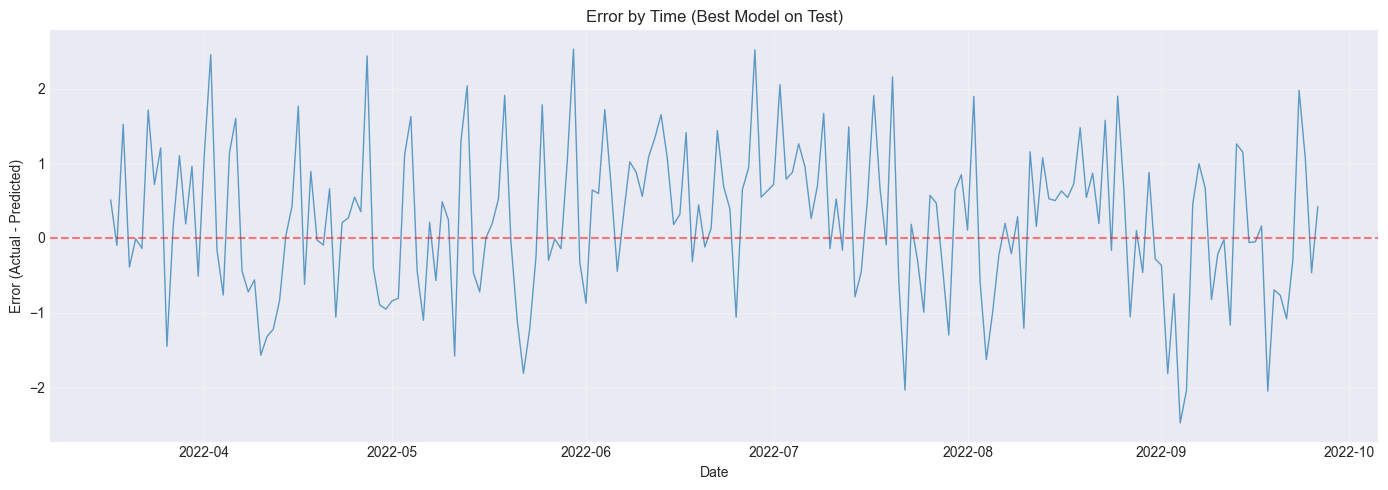

In [12]:
# figures/residuals_best.png
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(r1_test_preds, r1_test_targets - r1_test_preds, alpha=0.5)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(r1_test_targets - r1_test_preds, bins=50, alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/residuals_best.png', dpi=300, bbox_inches='tight')
plt.show()

# figures/error_by_time.png
plt.figure(figsize=(14, 5))
plt.plot(test_dates, r1_test_targets - r1_test_preds, linewidth=1, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Error by Time (Best Model on Test)')
plt.xlabel('Date')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/error_by_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Проверка перед сохранением:
print("Columns in runs.csv:")
print(runs_df.columns.tolist())

# Ожидаемые колонки:
expected_cols = ['experiment_id', 'task', 'dataset', 'seed', 'split_summary',
                 'window_size', 'horizon', 'model_summary', 'features_summary',
                 'scaler', 'optimizer', 'lr', 'epochs_trained',
                 'best_val_mae', 'best_val_rmse', 'best_val_mape',
                 'test_mae', 'test_rmse', 'test_mape', 'notes']

Columns in runs.csv:
['experiment_id', 'task', 'dataset', 'seed', 'split_summary', 'window_size', 'horizon', 'model_summary', 'features_summary', 'scaler', 'optimizer', 'lr', 'epochs_trained', 'best_val_mae', 'best_val_rmse', 'best_val_mape', 'test_mae', 'test_rmse', 'test_mape', 'notes']


In [ ]:
# Проверка содержимого конфига:
with open('artifacts/best_gru_config.json', 'r') as f:
    config = json.load(f)
    print("Config keys:", config.keys())мук
    

Config keys: dict_keys(['model_type', 'input_size', 'hidden_size', 'num_layers', 'dropout', 'batch_size', 'learning_rate', 'window_size', 'horizon', 'epochs', 'seed', 'scaler', 'best_val_loss', 'test_metrics'])
